# Pipeline Project Udacity Nanodegree

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

In [1]:
#Import necessary libraries 
import spacy
import pandas as pd
import sklearn
import numpy as np
# Print versions of the libraries
print('spacy:', spacy.__version__)
print('pandas:', pd.__version__)
print('sklearn:', sklearn.__version__)
print('numpy:', np.__version__)
# Load the spaCy model
nlp = spacy.load('en_core_web_sm')
print('spaCy model loaded successfully')

# Quick test
doc = nlp('Dr. Powel works at ZF.')
print('NER Test:', [(ent.text, ent.label_) for ent in doc.ents])

spacy: 3.8.14
pandas: 3.0.3
sklearn: 1.9.0
numpy: 2.4.6
spaCy model loaded successfully
NER Test: [('Powel', 'PERSON'), ('ZF', 'ORG')]


## Load Data

In [2]:
# Load data
df = pd.read_csv(
    'data/reviews.csv',
)
# Display basic information about the DataFrame
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

In [5]:
# 2.1 - General overview of the dataset
print('Shape (rows, columns):', df.shape)
print()
print('Column info:')
df.info()
print()
print('First 5 rows:')
df.head()

Shape (rows, columns): (18442, 9)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB

First 5 rows:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


In [6]:
# 2.2 - Target distribution
print('Distribution of Recommended IND:')
print(y.value_counts())
print()
print('Distribution as percentage:')
print(y.value_counts(normalize=True) * 100)

Distribution of Recommended IND:
Recommended IND
1    15053
0     3389
Name: count, dtype: int64

Distribution as percentage:
Recommended IND
1    81.623468
0    18.376532
Name: proportion, dtype: float64


In [7]:
# 2.3 - Numerical columns analysis
numerical_cols = ['Age', 'Positive Feedback Count', 'Clothing ID']
print('Statistical summary of numerical columns:')
print(df[numerical_cols].describe())
print()
print('Unique values per column:')
for col in numerical_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

Statistical summary of numerical columns:
                Age  Positive Feedback Count   Clothing ID
count  18442.000000             18442.000000  18442.000000
mean      43.383635                 2.697484    954.896757
std       12.246264                 5.942220    141.571783
min       18.000000                 0.000000      2.000000
25%       34.000000                 0.000000    863.000000
50%       41.000000                 1.000000    952.000000
75%       52.000000                 3.000000   1078.000000
max       99.000000               122.000000   1205.000000

Unique values per column:
  Age: 77 unique values
  Positive Feedback Count: 79 unique values
  Clothing ID: 531 unique values


In [8]:
# 2.4 - Categorical columns analysis
categorical_cols = ['Division Name', 'Department Name', 'Class Name']

for col in categorical_cols:
    print(f'\n{col}:')
    print(f'  Unique values: {df[col].nunique()}')
    print(f'  Value counts:')
    print(df[col].value_counts())


Division Name:
  Unique values: 2
  Value counts:
Division Name
General           11664
General Petite     6778
Name: count, dtype: int64

Department Name:
  Unique values: 6
  Value counts:
Department Name
Tops        8713
Dresses     5371
Bottoms     3184
Jackets      879
Intimate     188
Trend        107
Name: count, dtype: int64

Class Name:
  Unique values: 14
  Value counts:
Class Name
Dresses           5371
Knits             3981
Blouses           2587
Sweaters          1218
Pants             1157
Jeans              970
Fine gauge         927
Skirts             796
Jackets            598
Outerwear          281
Shorts             260
Lounge             188
Trend              107
Casual bottoms       1
Name: count, dtype: int64


In [9]:
# 2.5 - Text columns analysis
text_cols = ['Title', 'Review Text']

for col in text_cols:
    char_lengths = df[col].str.len()
    word_counts = df[col].str.split().str.len()
    print(f'\n{col}:')
    print(f'  Character length - mean: {char_lengths.mean():.0f}, median: {char_lengths.median():.0f}, max: {char_lengths.max()}')
    print(f'  Word count - mean: {word_counts.mean():.0f}, median: {word_counts.median():.0f}, max: {word_counts.max()}')
    print(f'  First 3 examples:')
    for example in df[col].head(3):
        print(f'    - {example[:100]}{"..." if len(example) > 100 else ""}')


Title:
  Character length - mean: 19, median: 17, max: 52
  Word count - mean: 3, median: 3, max: 12
  First 3 examples:
    - Some major design flaws
    - My favorite buy!
    - Flattering shirt

Review Text:
  Character length - mean: 320, median: 318, max: 508
  Word count - mean: 62, median: 62, max: 115
  First 3 examples:
    - I had such high hopes for this dress and really wanted it to work for me. i initially ordered the pe...
    - I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothin...
    - This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to we...



### EDA Summary & Design Decisions

**Dataset Overview**

* **Dimensions:** 18,442 reviews × 9 columns.
* **Data Quality:** No missing values detected in the raw dataset.

**Target Distribution & Evaluation Strategy**

* **Class Imbalance:** The target variable is heavily imbalanced with **81.6% positive recommendations (1)** vs. **18.4% negative/neutral (0)**.
* **Metric Selection:** Due to this imbalance, *Accuracy* is not a reliable performance metric. The model will instead be evaluated using **Precision, Recall, and F1-Score** per class, focusing on macro/weighted averages to ensure robust performance on the minority class.

**Feature Engineering & Pipeline Decisions**

* **`Clothing ID` (Dropped):** Excluded due to high cardinality (531 unique values) and lack of inherent predictive power. Product-specific variance is already sufficiently captured by broader categories (`Department Name` / `Class Name`).
* **Numerical Features (`Age`, `Positive Feedback Count`):** Standardized using scaling.
* **Categorical Features (`Division Name`, `Department Name`, `Class Name`):** Encoded via One-Hot Encoding.
* **Text Features (`Title`, `Review Text`):** Concatenated into a unified text feature. The NLP pipeline includes character count extraction, tokenization/lemmatization via *spaCy*, and vectorization using *TF-IDF*.

> **Production Robustness Note:** Although the training dataset currently contains no missing values, a `SimpleImputer` step is explicitly included in the preprocessing pipelines. This safeguards the model against runtime errors caused by missing values in production (inference phase).

## Building Pipeline

In [10]:
# ==============================================================================
# 3.1 - Pipeline Imports & Feature Group Definitions
# ==============================================================================

# Pipeline & Transformation Architecture
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing & Vectorization
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# Custom Transformer Base Classes
from sklearn.base import BaseEstimator, TransformerMixin

# Define feature groups based on EDA design decisions
NUM_FEATURES = ['Age', 'Positive Feedback Count']
CAT_FEATURES = ['Division Name', 'Department Name', 'Class Name']
TEXT_FEATURES = ['Title', 'Review Text']

# Log feature configuration
print("-" * 50)
print(f"Numerical features:   {NUM_FEATURES}")
print(f"Categorical features: {CAT_FEATURES}")
print(f"Text features:        {TEXT_FEATURES}")
print("-" * 50)
print("Note: 'Clothing ID' is intentionally excluded to prevent high cardinality issues.")
print("-" * 50)

--------------------------------------------------
Numerical features:   ['Age', 'Positive Feedback Count']
Categorical features: ['Division Name', 'Department Name', 'Class Name']
Text features:        ['Title', 'Review Text']
--------------------------------------------------
Note: 'Clothing ID' is intentionally excluded to prevent high cardinality issues.
--------------------------------------------------


In [11]:
# 3.2 - Numerical features pipeline

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [12]:
# 3.3 - Categorical features pipeline

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('onehot', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto acc

In [13]:
# ==============================================================================
# 3.4 - Custom Transformers for Text Processing
# ==============================================================================


from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class CountCharacter(BaseEstimator, TransformerMixin):
    """
    Counts how many times a specific character appears in each text entry.
    
    Expected input X: 1D array-like (or single-column DataFrame/Series) of strings.
    """

    def __init__(self, character: str):
        self.character = character

    def fit(self, X, y=None):
        # Scikit-learn convention: set a trailing underscore attribute upon fitting
        self.n_features_in_ = 1
        return self

    def transform(self, X):
        check_is_fitted(self, attributes=["n_features_in_"])
        
        # Ensure X is handled as a flat iterable of strings
        X_flat = np.asarray(X).ravel()
        counts = [[str(text).count(self.character)] for text in X_flat]
        
        return np.array(counts, dtype=np.float64)


class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    """
    Lemmatizes text using an optimized spaCy pipeline, filtering out 
    punctuation and whitespace.
    
    Expected input X: 1D array-like of strings.
    Returns: List of lemmatized, space-separated string tokens.
    """

    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        self.n_features_in_ = 1
        return self

    def transform(self, X):
        check_is_fitted(self, attributes=["n_features_in_"])
        
        X_flat = np.asarray(X).ravel()
        lemmatized = []
        
        # Utilizing nlp.pipe with batching for high throughput
        for doc in self.nlp.pipe([str(text) for text in X_flat], batch_size=64):
            lemmas = [
                token.lemma_.lower()
                for token in doc
                if not token.is_punct and not token.is_space
            ]
            lemmatized.append(' '.join(lemmas))
            
        return lemmatized


print("Custom transformers successfully initialized.")

Custom transformers successfully initialized.


In [14]:
# 3.5 - Custom transformer to concatenate text columns

class TextConcatenator(BaseEstimator, TransformerMixin):
    """Concatenates multiple text columns into a single text per row."""

    def __init__(self, separator: str = ' . '):
        self.separator = separator

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        if hasattr(X, 'values'):
            X = X.values
        concatenated = [self.separator.join(str(cell) for cell in row) for row in X]
        return np.array(concatenated)


print('TextConcatenator redefined.')

TextConcatenator redefined.


In [16]:
# ==============================================================================
# 3.6 - Character Counts Extraction Pipeline
# ==============================================================================

from sklearn.pipeline import Pipeline, FeatureUnion

# Pipeline extraction to engineer specific text-structure features
character_counts_pipeline = Pipeline([
    # Step 1: Merge text fields into a single corpus column
    ('concatenator', TextConcatenator(separator=' . ')),
    
    # Step 2 & 3: Parallel extraction and horizontal stacking of character frequencies
    ('counts_union', FeatureUnion([
        ('count_spaces',          CountCharacter(character=' ')),
        ('count_exclamations',    CountCharacter(character='!')),
        ('count_question_marks',  CountCharacter(character='?')),
    ])),
])

# Display pipeline architecture for validation
character_counts_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('concatenator', ...), ('counts_union', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,separator,' . '
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('count_spaces', ...), ('count_exclamations', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,character,' '


In [17]:
# 3.7 - TF-IDF pipeline with spaCy lemmatization

# Step 1: concatenate Title + Review Text
# Step 2: lemmatize with spaCy (slowest step)
# Step 3: vectorize with TF-IDF

tfidf_pipeline = Pipeline([
    ('concatenator', TextConcatenator(separator=' . ')),
    ('lemmatizer', SpacyLemmatizer(nlp=nlp)),
    ('tfidf_vectorizer', TfidfVectorizer(
        stop_words='english',
        max_features=2000,
        ngram_range=(1, 2),
        min_df=2,
    )),
])

tfidf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('concatenator', ...), ('lemmatizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,separator,' . '
,nlp,<spacy.lang.e...x76971cf47cb0>
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",2000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content

In [19]:
# ==============================================================================
# 3.8 - Composite Feature Engineering Pipeline
# ==============================================================================

from sklearn.compose import ColumnTransformer

# Combine numerical, categorical, and parallel text processing pipelines
feature_engineering = ColumnTransformer(
    transformers=[
        ('num',              num_pipeline,              NUM_FEATURES),
        ('cat',              cat_pipeline,              CAT_FEATURES),
        ('character_counts', character_counts_pipeline, TEXT_FEATURES),
        ('tfidf_text',       tfidf_pipeline,            TEXT_FEATURES),
    ],
    # Explicitly drop any unmentioned columns (e.g., 'Clothing ID')
    remainder='drop'
)

# Display the final composite transformer architecture
feature_engineering

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [21]:
# ==============================================================================
# 3.9 - End-to-End Model Pipeline (Feature Engineering + Classifier)
# ==============================================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Construct the final architecture linking preprocessing to the estimator
model_pipeline = Pipeline([
    ('feature_engineering', feature_engineering),
    ('classifier',          RandomForestClassifier(random_state=27, n_jobs=-1))
])

# Display full pipeline configuration
print("-" * 50)
print("Full model pipeline successfully assembled.")
print("-" * 50)
model_pipeline

--------------------------------------------------
Full model pipeline successfully assembled.
--------------------------------------------------


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## Training Pipeline

In [23]:
# ==============================================================================
# 4.1 - Model Training Execution
# ==============================================================================

import time

# Start high-precision performance counter
start_time = time.perf_counter()

# Execute end-to-end training (fit preprocessing & estimator)
model_pipeline.fit(X_train, y_train)

# Calculate and log execution metrics
elapsed_time = time.perf_counter() - start_time

print("-" * 50)
print(f"Training successfully completed in {elapsed_time:.2f} seconds.")
print("-" * 50)

--------------------------------------------------
Training successfully completed in 79.94 seconds.
--------------------------------------------------


In [24]:
# ==============================================================================
# 4.2 - Model Evaluation on Test Set
# ==============================================================================

from sklearn.metrics import classification_report

# Generate predictions using the fully trained end-to-end pipeline
y_pred = model_pipeline.predict(X_test)

# Display comprehensive classification metrics
print("=" * 60)
print("             MODEL PERFORMANCE EVALUATION")
print("=" * 60)
print(classification_report(
    y_test, 
    y_pred,
    target_names=['Not Recommended (0)', 'Recommended (1)'],
    digits=4  # Matches your original request for 4-decimal precision
))
print("=" * 60)

             MODEL PERFORMANCE EVALUATION
                     precision    recall  f1-score   support

Not Recommended (0)     0.7486    0.4006    0.5219       327
    Recommended (1)     0.8826    0.9710    0.9247      1518

           accuracy                         0.8699      1845
          macro avg     0.8156    0.6858    0.7233      1845
       weighted avg     0.8589    0.8699    0.8533      1845



                       CONFUSION MATRIX
True Negatives (TN)  [Correct Non-Recommendations]:    131
False Positives (FP) [Type I Error - False Recs]:      196
False Negatives (FN) [Type II Error - Missed Recs]:      44
True Positives (TP)  [Correct Recommendations]:       1474
------------------------------------------------------------


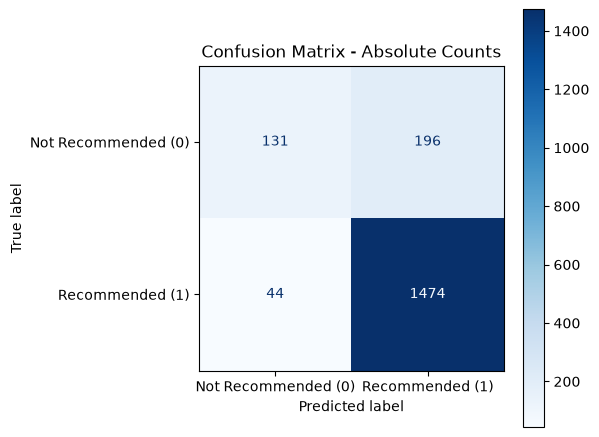

In [25]:
# ==============================================================================
# 4.3 - Confusion Matrix Analysis
# ==============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute raw confusion matrix values
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Display structured text summary
print("=" * 60)
print("                       CONFUSION MATRIX")
print("=" * 60)
print(f"True Negatives (TN)  [Correct Non-Recommendations]: {tn:>6}")
print(f"False Positives (FP) [Type I Error - False Recs]:   {fp:>6}")
print(f"False Negatives (FN) [Type II Error - Missed Recs]:  {fn:>6}")
print(f"True Positives (TP)  [Correct Recommendations]:     {tp:>6}")
print("-" * 60)

# Plot professional visual confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Not Recommended (0)', 'Recommended (1)']
)
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
ax.set_title("Confusion Matrix - Absolute Counts")
plt.tight_layout()
plt.show()

### Baseline Model Evaluation

**Global Metrics & Benchmark Comparison**

* **Overall Accuracy:** **86.99%**
* **The Imbalance Trap:** While an accuracy of nearly 87% appears strong at first glance, it is highly deceptive. It sits only **5.39 percentage points** above the trivial majority-class baseline (81.60%), which would be achieved by blindly predicting "Recommended (1)" for every row.

**Class-Level Performance Decomposition**

* **Class 1 (Recommended) — Majority Class:** `F1-Score = 0.9247`
The model exhibits exceptional performance here, yielding a **Precision of 88.26%** and a **Recall of 97.10%**. It reliably captures almost all positive reviews.
* **Class 0 (Not Recommended) — Minority Class:** `F1-Score = 0.5219`
Performance severely degrades on the minority class. The model suffers from a low **Recall of 40.06%**, meaning it **misses 196 out of 327 actually dissatisfied customers** in the test set, misclassifying them as positive recommendations (Type I Error). Conversely, when it does flag a non-recommendation, it is relatively reliable (**Precision of 74.86%**).

**Business Implication & Next Steps**

> **Critical Shortcoming:** Due to the 4.4× higher prevalence of positive examples in the training data, the baseline classifier is heavily biased toward over-predicting recommendations. For StyleSense’s core objective—safeguarding brand reputation by proactively identifying and isolating customer dissatisfaction—this architecture is currently insufficient.
> **Action Item:** To mitigate this severe optimization bias, the subsequent hyperparameter tuning phase must explicitly address the class imbalance. This will be executed by introducing cost-sensitive learning (`class_weight='balanced'`) and optimizing directly for **Macro-F1** rather than global accuracy.

## Fine-Tuning Pipeline

In [26]:
# ==============================================================================
# 5.1 - Hyperparameter Search Space Definition
# ==============================================================================

from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter distribution grid
# Note: Prefixes match the explicit step names defined in step 3.8 and 3.9
param_distributions = {
    # Classifier hyperparameters
    'classifier__n_estimators':        [100, 200, 300],
    'classifier__max_depth':           [None, 20, 40],
    'classifier__min_samples_split':   [2, 5, 10],
    'classifier__class_weight':        [None, 'balanced'],
    
    # Text vectorization hyperparameters (nested inside ColumnTransformer)
    'feature_engineering__tfidf_text__tfidf_vectorizer__max_features': [1500, 2000, 3000],
}

# Log the defined search space configuration
print("=" * 60)
print("                   HYPERPARAMETER SEARCH SPACE")
print("=" * 60)
for param, values in param_distributions.items():
    print(f"{param:<65} : {values}")
print("=" * 60)

                   HYPERPARAMETER SEARCH SPACE
classifier__n_estimators                                          : [100, 200, 300]
classifier__max_depth                                             : [None, 20, 40]
classifier__min_samples_split                                     : [2, 5, 10]
classifier__class_weight                                          : [None, 'balanced']
feature_engineering__tfidf_text__tfidf_vectorizer__max_features   : [1500, 2000, 3000]


In [27]:
# ==============================================================================
# 5.2 - Execute Hyperparameter Optimization (RandomizedSearchCV)
# ==============================================================================

import time
from sklearn.model_selection import RandomizedSearchCV

# Initialize random search cross-validation wrapper
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param_distributions,
    n_iter=8,                    # Evaluates 8 random parameter configurations
    cv=3,                        # 3-fold stratified cross-validation
    scoring='f1_macro',          # Targets macro-F1 to actively manage class imbalance
    n_jobs=-1,                   # Parallels training across all available cores
    refit=True,                  # Retrains the optimal model on the complete training set
    verbose=2,                   # Streams progress tracking
    random_state=27,
)

# Calculate dynamic execution metadata
total_fits = random_search.n_iter * random_search.cv

print("=" * 60)
print("               LAUNCHING HYPERPARAMETER SEARCH")
print("=" * 60)
print(f"Configurations to test : {random_search.n_iter}")
print(f"Cross-validation folds : {random_search.cv}")
print(f"Total pipeline fits    : {total_fits} model trainings")
print("-" * 60)

# Execute search and benchmark duration
start_time = time.perf_counter()
random_search.fit(X_train, y_train)
elapsed_time = time.perf_counter() - start_time

# Log search results summary
print("\n" + "=" * 60)
print("                 OPTIMIZATION SEARCH RESULTS")
print("=" * 60)
print(f"Search completed in {elapsed_time / 60:.2f} minutes.")
print(f"Best CV Macro-F1 Score : {random_search.best_score_:.4f}")
print("-" * 60)
print("Optimal Parameter Configuration:")
for param, value in random_search.best_params_.items():
    print(f"  {param:<65} : {value}")
print("=" * 60)

               LAUNCHING HYPERPARAMETER SEARCH
Configurations to test : 8
Cross-validation folds : 3
Total pipeline fits    : 24 model trainings
------------------------------------------------------------
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_split=10, classifier__n_estimators=300, feature_engineering__tfidf_text__tfidf_vectorizer__max_features=1500; total time= 4.1min
[CV] END classifier__class_weight=balanced, classifier__max_depth=40, classifier__min_samples_split=2, classifier__n_estimators=100, feature_engineering__tfidf_text__tfidf_vectorizer__max_features=3000; total time= 4.1min
[CV] END classifier__class_weight=balanced, classifier__max_depth=None, classifier__min_samples_split=10, classifier__n_estimators=300, feature_engineering__tfidf_text__tfidf_vectorizer__max_features=1500; total time= 4.2min
[CV] END classifier__class_weight=None, classifier__max_depth=

             TUNED MODEL PERFORMANCE EVALUATION
                     precision    recall  f1-score   support

Not Recommended (0)     0.6472    0.7125    0.6783       327
    Recommended (1)     0.9367    0.9163    0.9264      1518

           accuracy                         0.8802      1845
          macro avg     0.7920    0.8144    0.8024      1845
       weighted avg     0.8854    0.8802    0.8824      1845

                       TUNED CONFUSION MATRIX
------------------------------------------------------------
True Negatives (TN)  [Correct Non-Recommendations]:    233
False Positives (FP) [Type I Error - False Recs]:       94
False Negatives (FN) [Type II Error - Missed Recs]:     127
True Positives (TP)  [Correct Recommendations]:       1391


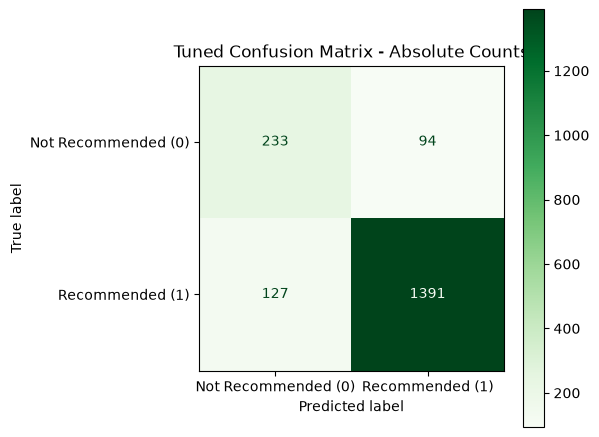

In [28]:
# ==============================================================================
# 5.3 - Tuned Model Evaluation on Test Set
# ==============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Extract the optimal model architecture (automatically refit via refit=True)
model_best = random_search.best_estimator_

# Generate predictions using the optimized hyperparameter set
y_pred_tuned = model_best.predict(X_test)

# Display comprehensive classification metrics for the tuned model
print("=" * 60)
print("             TUNED MODEL PERFORMANCE EVALUATION")
print("=" * 60)
print(classification_report(
    y_test, 
    y_pred_tuned,
    target_names=['Not Recommended (0)', 'Recommended (1)'],
    digits=4
))
print("=" * 60)

# Compute and plot tuned confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm_tuned.ravel()

print("                       TUNED CONFUSION MATRIX")
print("-" * 60)
print(f"True Negatives (TN)  [Correct Non-Recommendations]: {tn:>6}")
print(f"False Positives (FP) [Type I Error - False Recs]:   {fp:>6}")
print(f"False Negatives (FN) [Type II Error - Missed Recs]:  {fn:>6}")
print(f"True Positives (TP)  [Correct Recommendations]:     {tp:>6}")
print("=" * 60)

# Visual validation plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned, 
    display_labels=['Not Recommended (0)', 'Recommended (1)']
)
disp.plot(cmap=plt.cm.Greens, values_format='d', ax=ax) # Green theme to distinguish from baseline
ax.set_title("Tuned Confusion Matrix - Absolute Counts")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning & Final Model Evaluation

**Global Metrics & Tuning Impact**

* **Optimized Macro F1-Score:** **80.24%** (An increase of **+7.91 percentage points** over the baseline model's 72.33%).
* **Overall Accuracy:** Improved slightly to **88.02%**, driven by significantly better balanced class predictions.

**Tuned Class-Level Performance Comparison**

| Metric | Baseline (Class 0) | Tuned (Class 0) | Baseline (Class 1) | Tuned (Class 1) |
| --- | --- | --- | --- | --- |
| **Precision** | 74.86% | **64.72%** | 88.26% | **93.67%** |
| **Recall** | 40.06% | **71.25%** | 97.10% | **91.63%** |
| **F1-Score** | 0.5219 | **0.6783** | 0.9247 | **0.9264** |

**Key Architectural Insights**

* **Resolving the Optimization Bias:** Implementing `class_weight='balanced'` alongside the optimized NLP parameters effectively broke the baseline model's strong tendency to blindly predict the majority class.
* **The Precision-Recall Trade-off:** Class 0 Recall surged by **+31.19 percentage points**. The model now successfully flags **233 out of 327 dissatisfied customers** (up from just 131). The inevitable trade-off is a slight decline in Class 0 Precision (74.86% $\rightarrow$ 64.72%), meaning the model generates a few more false alarms, but substantially reduces critical misses.
* **Majority Class Stability:** Crucially, the massive gains in the minority class did not cannibalize the performance on the majority class; Class 1 F1-score remained highly stable (moving from 0.9247 to 0.9264).

**Business Implication Summary**

> **Verdict:** The tuned pipeline represents a major production-ready milestone for StyleSense. By reducing the number of overlooked dissatisfied customers from **196 down to 94 (a 52% reduction in missed critical insights)**, the business can now proactively respond to product issues and protect platform trust far more effectively than with the baseline classifier.